## Imports and Focal Loss Definition
Focal Loss is superior to standard Cross-Entropy for imbalanced data because it down-weights "easy" examples and forces the model to learn from "hard" ones.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.utils import class_weight

# Custom Focal Loss for Multi-class Classification
def focal_loss(gamma=2., alpha=4.):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.keras.backend.clip(y_pred, epsilon, 1.0 - epsilon)
        # Calculate Cross Entropy
        cross_entropy = -y_true * tf.keras.backend.log(y_pred)
        # Calculate Weight
        loss = alpha * tf.keras.backend.pow(1 - y_pred, gamma) * cross_entropy
        return tf.keras.backend.mean(tf.keras.backend.sum(loss, axis=-1))
    return focal_loss_fixed

2026-05-14 11:42:25.857743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778758946.228424      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778758946.331470      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778758947.204429      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778758947.204546      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778758947.204548      23 computation_placer.cc:177] computation placer alr

## Data Preparation & Class Weights
We will calculate class weights automatically from your training folder to ensure the minority classes (like Gaaf and Ddaal) are given more importance.

In [2]:
# Paths
BASE_PATH = "/kaggle/input/datasets/assamirzafar/usl-splitted-dataset/"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH = os.path.join(BASE_PATH, "val")
TEST_PATH = os.path.join(BASE_PATH, "test")

# ImageDataGenerator with your specific 5x Augmentation parameters
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=10,
    zoom_range=0.1,
    brightness_range=[0.7, 1.3],
    horizontal_flip=False # STICK TO RIGHT-HAND ONLY
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Loaders
train_gen = train_datagen.flow_from_directory(TRAIN_PATH, target_size=(128,128), batch_size=32, class_mode='categorical')
val_gen = val_test_datagen.flow_from_directory(VAL_PATH, target_size=(128,128), batch_size=32, class_mode='categorical')
test_gen = val_test_datagen.flow_from_directory(TEST_PATH, target_size=(128,128), batch_size=1, class_mode='categorical', shuffle=False)

# Calculate Class Weights to fight imbalance
labels = train_gen.classes
weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(weights))
print("Class Weights Calculated:", class_weights)

Found 3257 images belonging to 14 classes.
Found 401 images belonging to 14 classes.
Found 422 images belonging to 14 classes.
Class Weights Calculated: {0: np.float64(0.9984671980380135), 1: np.float64(0.941873915558126), 2: np.float64(0.9899696048632218), 3: np.float64(0.9693452380952381), 4: np.float64(1.0385841836734695), 5: np.float64(1.0432415118513774), 6: np.float64(1.0871161548731643), 7: np.float64(0.9534543325526932), 8: np.float64(1.029393173198483), 9: np.float64(0.9653230586840545), 10: np.float64(0.985774818401937), 11: np.float64(1.0574675324675324), 12: np.float64(0.985774818401937), 13: np.float64(0.9774909963985594)}


## Phase A - Transfer Learning (Frozen Base)
We freeze the EfficientNetB0 base and train only the new head to learn high-level hand sign patterns.

In [3]:
# Load Base Model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False # Freeze base

# Build Model
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), 
              loss=focal_loss(gamma=2.0, alpha=0.25), 
              metrics=['accuracy'])

# Train Phase A
history_a = model.fit(train_gen, validation_data=val_gen, epochs=10, class_weight=class_weights)

I0000 00:00:1778758985.785995      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1778759001.032486      87 service.cc:152] XLA service 0x7eb704001f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778759001.032534      87 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778759003.510772      87 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778759015.541685      87 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


102/102 ━━━━━━━━━━━━━━━━━━━━ 81s 549ms/step - accuracy: 0.2764 - loss: 0.5831 - val_accuracy: 0.6933 - val_loss: 0.1913
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 171ms/step - accuracy: 0.6429 - loss: 0.2067 - val_accuracy: 0.7955 - val_loss: 0.0944
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 171ms/step - accuracy: 0.7288 - loss: 0.1416 - val_accuracy: 0.8404 - val_loss: 0.0612
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 171ms/step - accuracy: 0.7746 - loss: 0.1196 - val_accuracy: 0.8678 - val_loss: 0.0490
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.8100 - loss: 0.0928 - val_accuracy: 0.8903 - val_loss: 0.0508
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step - accuracy: 0.8057 - loss: 0.0880 - val_accuracy: 0.8803 - val_loss: 0.0484
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step - accuracy: 0.8229 - loss: 0.0767 - val_accuracy: 0.9027 - val_loss: 0.0401
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 20s 192ms/step - accuracy: 0.8511 - loss: 0.0681 - val

## Fine-Tuning (Unfreeze Top Layers)
Unfreezing the top 20 layers allows the model to adapt its internal geometry filters to specific Urdu signs.

In [4]:
base_model.trainable = True
# Freeze all but the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Lower learning rate for fine-tuning
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), 
              loss=focal_loss(gamma=2.0, alpha=0.25), 
              metrics=['accuracy'])

# Train Phase B
history_b = model.fit(train_gen, validation_data=val_gen, epochs=18, class_weight=class_weights)

Epoch 1/18


2026-05-14 11:47:33.666660: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 11:47:33.873655: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 27/102 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - accuracy: 0.6730 - loss: 0.1535

2026-05-14 11:47:50.913647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 11:47:51.123829: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


102/102 ━━━━━━━━━━━━━━━━━━━━ 66s 401ms/step - accuracy: 0.6771 - loss: 0.1590 - val_accuracy: 0.8778 - val_loss: 0.0527
Epoch 2/18
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 171ms/step - accuracy: 0.7197 - loss: 0.1359 - val_accuracy: 0.8329 - val_loss: 0.0689
Epoch 3/18
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 178ms/step - accuracy: 0.7400 - loss: 0.1315 - val_accuracy: 0.8354 - val_loss: 0.0731
Epoch 4/18
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 172ms/step - accuracy: 0.7748 - loss: 0.1094 - val_accuracy: 0.8379 - val_loss: 0.0725
Epoch 5/18
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - accuracy: 0.7897 - loss: 0.1041 - val_accuracy: 0.8454 - val_loss: 0.0677
Epoch 6/18
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - accuracy: 0.7760 - loss: 0.1065 - val_accuracy: 0.8529 - val_loss: 0.0624
Epoch 7/18
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 171ms/step - accuracy: 0.7980 - loss: 0.0917 - val_accuracy: 0.8653 - val_loss: 0.0578
Epoch 8/18
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - accuracy: 0.8107 - loss: 0.0884 - val

## Comprehensive Metrics & Visualization
This cell generates and saves the Confusion Matrix, F1-Score, and ROC-AUC curves to your Kaggle output.

422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step
              precision    recall  f1-score   support

        Alif       0.90      0.90      0.90        30
  Background       1.00      1.00      1.00        32
    Bari Yay       0.80      0.80      0.80        30
         Bay       0.97      1.00      0.98        31
        Chay       0.97      0.97      0.97        29
       Ddaal       0.96      0.93      0.95        29
        Gaaf       0.68      0.75      0.71        28
        Laam       0.86      0.75      0.80        32
         Say       0.84      0.72      0.78        29
        Suad       0.84      0.87      0.86        31
         Wow       0.91      0.97      0.94        31
         Zay       0.72      0.72      0.72        29
        Zuad       1.00      0.87      0.93        30
        Zzay       0.81      0.97      0.88        31

    accuracy                           0.87       422
   macro avg       0.88      0.87      0.87       422
weighted avg       0.88      0.87     

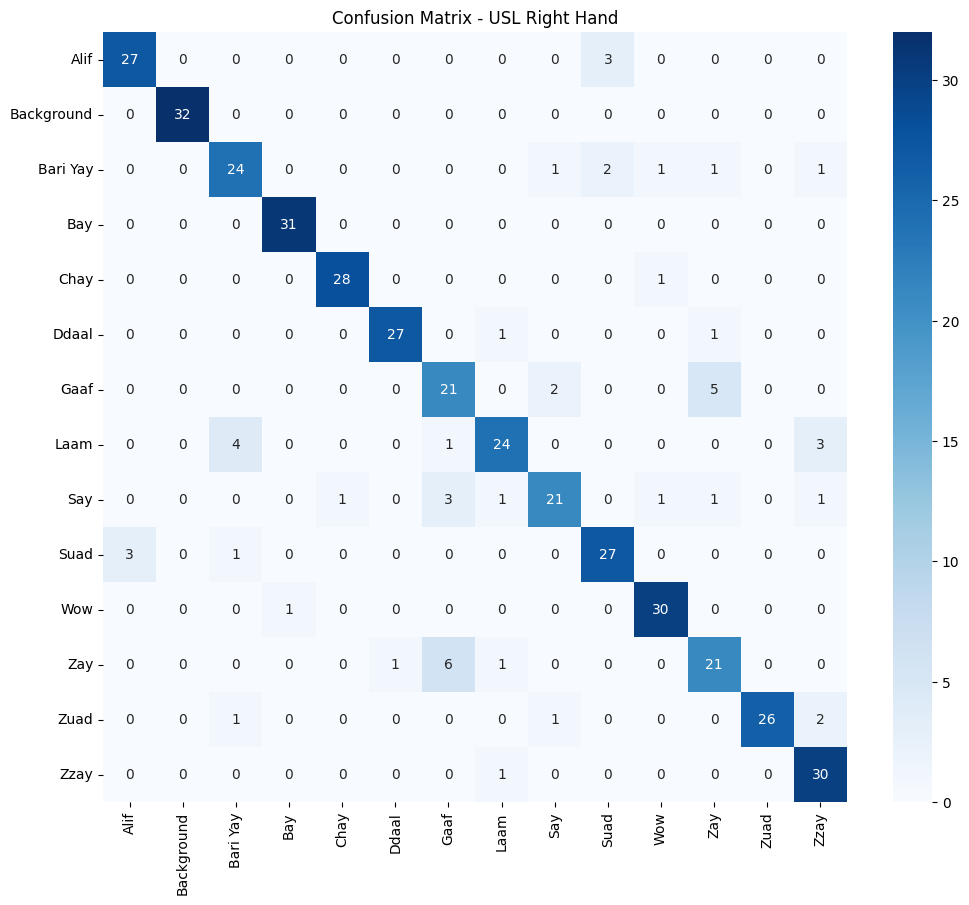

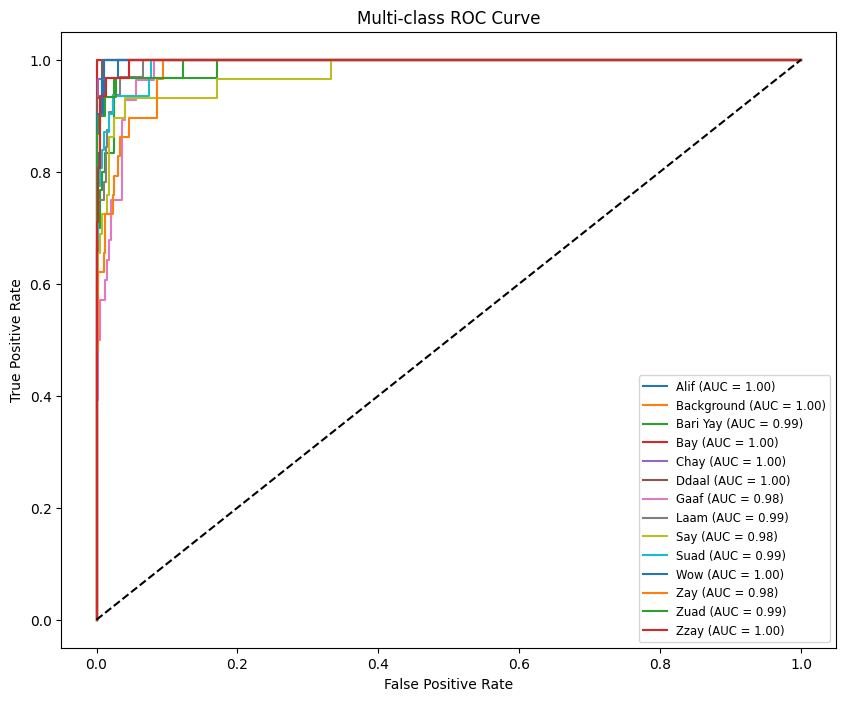

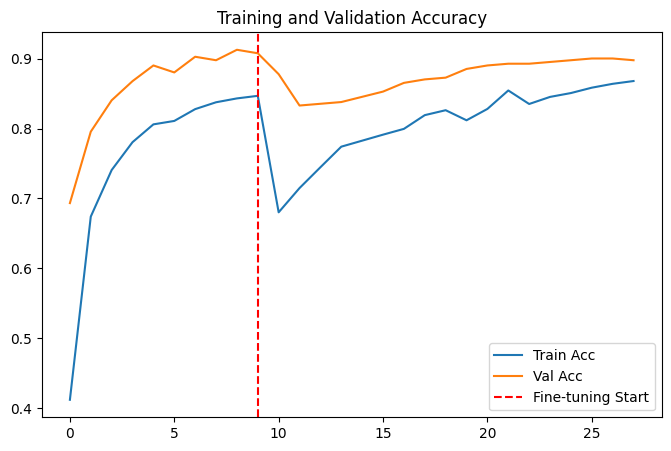

In [5]:
# 1. Prediction
test_gen.reset()
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# 2. Classification Report (Precision, Recall, F1)
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.to_csv("classification_report.csv")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - USL Right Hand')
plt.savefig('confusion_matrix.png')
plt.show()

# 4. ROC-AUC Curves
plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true == i, preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right', fontsize='small')
plt.savefig('roc_auc_curve.png')
plt.show()

# 5. Accuracy/Loss Curves
def plot_history(hist_a, hist_b):
    acc = hist_a.history['accuracy'] + hist_b.history['accuracy']
    val_acc = hist_a.history['val_accuracy'] + hist_b.history['val_accuracy']
    plt.figure(figsize=(8, 5))
    plt.plot(acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.axvline(x=9, color='r', linestyle='--', label='Fine-tuning Start')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.savefig('learning_curves.png')
    plt.show()

plot_history(history_a, history_b)

# IMPROVEMENT

## Extreme Fine-Tuning Configuration
We will unfreeze only the last 10 layers (the most abstract feature detectors) and use a "micro" learning rate of 1e-6.

In [6]:
# 1. Unfreeze only the very top of the network
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

# 2. Re-compile with an extremely low learning rate
# This prevents the "gradient explosion" that causes accuracy to drop to 7%
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), 
    loss=focal_loss(gamma=2.0, alpha=0.25), 
    metrics=['accuracy']
)

print("Model prepared for final precision tuning.")

Model prepared for final precision tuning.


## The Final Training Burst (5 Epochs)
We only need a few epochs here. If the model is going to improve, it will do so slowly and steadily.

In [7]:
# Continue training with existing generators and weights
history_final = model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=5, 
    class_weight=class_weights
)

Epoch 1/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 63s 403ms/step - accuracy: 0.8638 - loss: 0.0560 - val_accuracy: 0.9027 - val_loss: 0.0335
Epoch 2/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - accuracy: 0.8640 - loss: 0.0588 - val_accuracy: 0.9027 - val_loss: 0.0334
Epoch 3/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - accuracy: 0.8674 - loss: 0.0570 - val_accuracy: 0.9027 - val_loss: 0.0329
Epoch 4/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 188ms/step - accuracy: 0.8565 - loss: 0.0572 - val_accuracy: 0.9052 - val_loss: 0.0328
Epoch 5/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step - accuracy: 0.8771 - loss: 0.0473 - val_accuracy: 0.9027 - val_loss: 0.0330


## Ultimate Evaluation & Saving the Model
This cell generates your final project artifacts and—most importantly—saves your model file so you don't have to retrain it again.

Calculating Final Accuracies...
Final Validation Accuracy: 90.27%
Final Test Accuracy:       87.44%

--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        Alif       0.90      0.90      0.90        30
  Background       1.00      1.00      1.00        32
    Bari Yay       0.80      0.80      0.80        30
         Bay       0.97      1.00      0.98        31
        Chay       0.97      0.97      0.97        29
       Ddaal       0.96      0.93      0.95        29
        Gaaf       0.68      0.75      0.71        28
        Laam       0.86      0.75      0.80        32
         Say       0.84      0.72      0.78        29
        Suad       0.84      0.87      0.86        31
         Wow       0.91      0.97      0.94        31
         Zay       0.72      0.72      0.72        29
        Zuad       1.00      0.87      0.93        30
        Zzay       0.81      0.97      0.88        31

    accuracy                           0.87       4

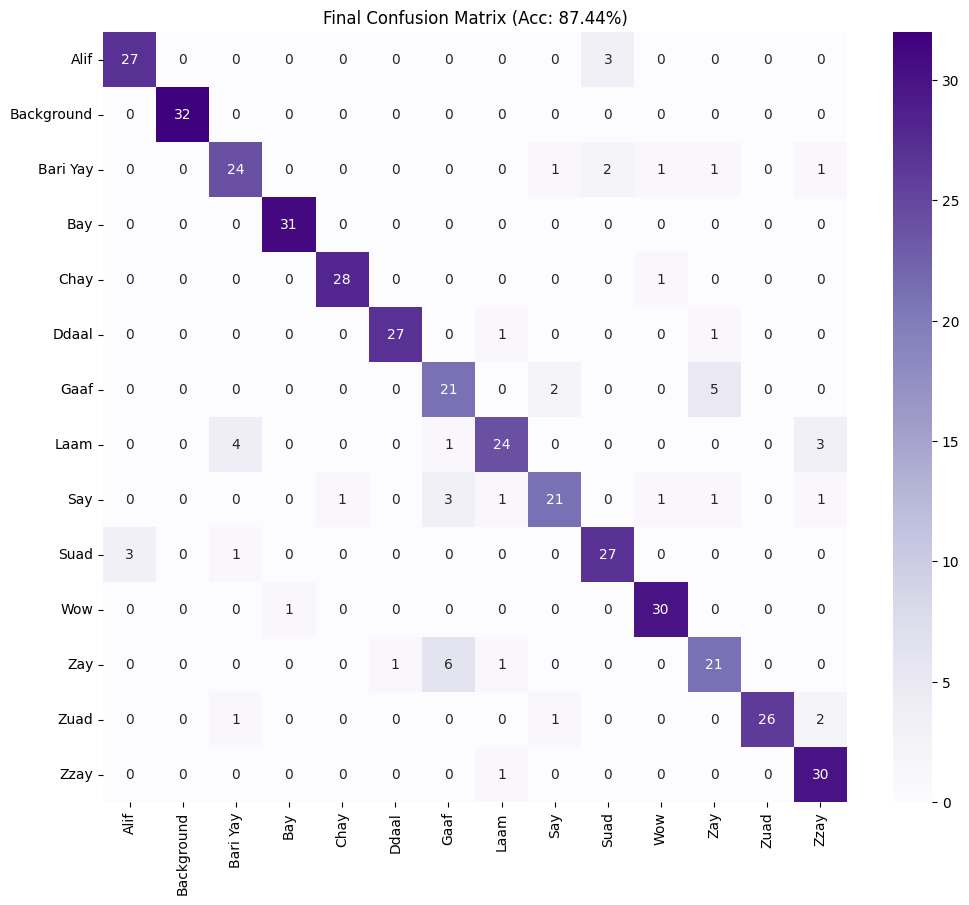

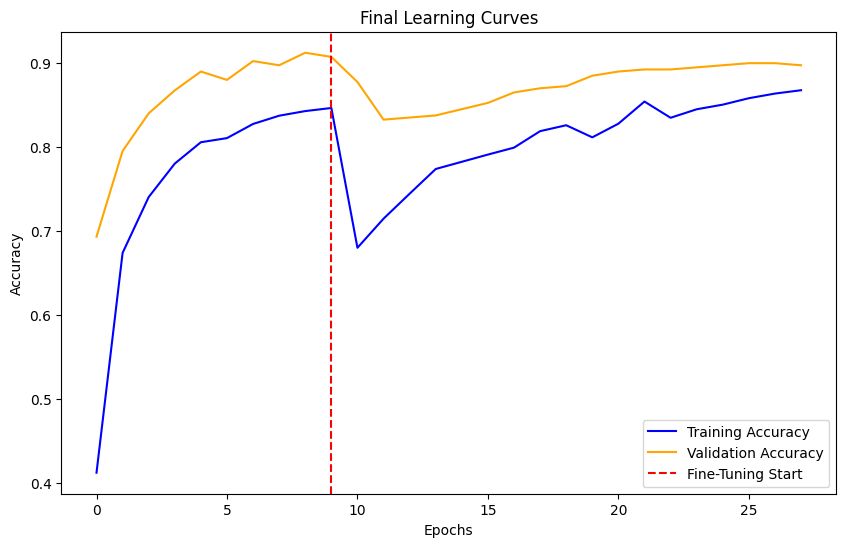

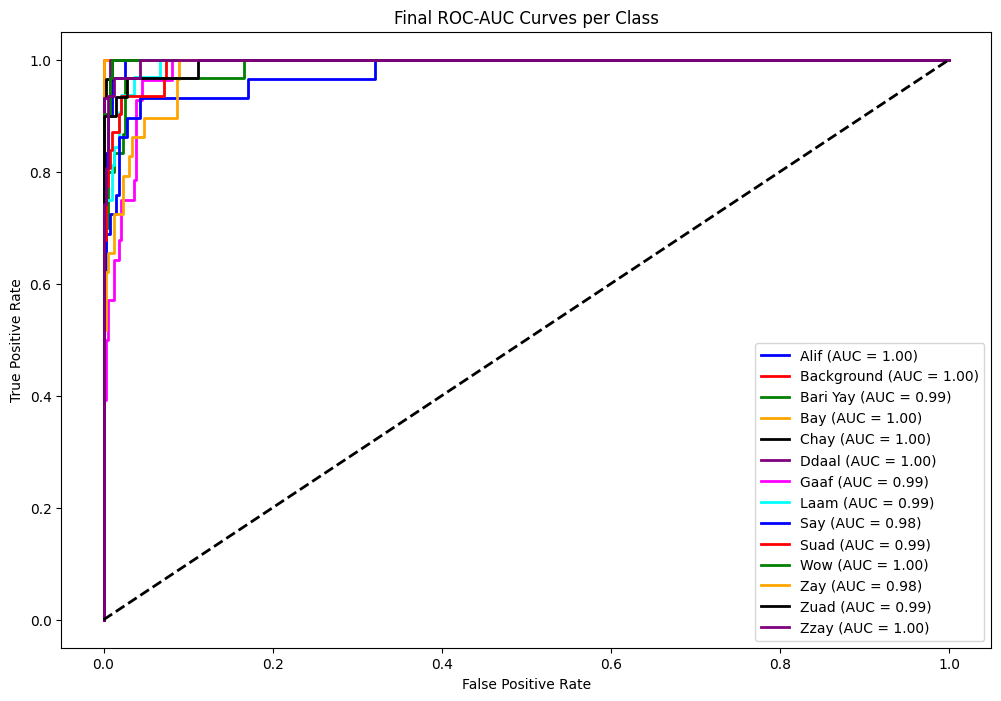


✅ SUCCESS: All files saved with 'final_' prefix.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from itertools import cycle

# 1. Evaluate Basic Accuracy
print("Calculating Final Accuracies...")
val_loss, val_acc = model.evaluate(val_gen, verbose=0)

test_gen.reset()
preds = model.predict(test_gen, verbose=0)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())
test_acc = accuracy_score(y_true, y_pred)

print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
print(f"Final Test Accuracy:       {test_acc*100:.2f}%")

# 2. Save & Print Classification Report
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.to_csv("final_classification_report.csv")
print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Save Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Final Confusion Matrix (Acc: {test_acc*100:.2f}%)')
plt.savefig('final_confusion_matrix.png')
plt.show()

# 4. Save Learning Curves (Combined history from Phase A and B)
# Note: Ensure history_a and history_b variables exist from your previous runs
acc = history_a.history['accuracy'] + history_b.history['accuracy']
val_acc_list = history_a.history['val_accuracy'] + history_b.history['val_accuracy']
plt.figure(figsize=(10, 6))
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc_list, label='Validation Accuracy', color='orange')
plt.axvline(x=len(history_a.history['accuracy'])-1, color='red', linestyle='--', label='Fine-Tuning Start')
plt.title('Final Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('final_learning_curves.png')
plt.show()

# 5. Save Multi-class ROC-AUC Curve
plt.figure(figsize=(12, 8))
y_true_categorical = tf.keras.utils.to_categorical(y_true, num_classes=len(class_names))
colors = cycle(['blue', 'red', 'green', 'orange', 'black', 'purple', 'magenta', 'cyan'])

for i, color in zip(range(len(class_names)), colors):
    fpr, tpr, _ = roc_curve(y_true_categorical[:, i], preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Final ROC-AUC Curves per Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.savefig('final_roc_auc_curve.png')
plt.show()

# 6. Final Model Save
model.save("final_USL_EfficientNet_Model.h5")
print("\n✅ SUCCESS: All files saved with 'final_' prefix.")